# Figure 6: SCD - SSCR Breakdown 

To prepare plot data run: make paper_fig_6

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


sns.set_context('paper', font_scale=2., rc={"lines.linewidth": 1.75} )
sns.set_style({'font.weight': 'bold'})

# Markers
plt.rcParams['lines.markersize'] = 6.5
plt.rcParams['lines.linewidth'] = 1.75
plt.rcParams['figure.figsize'] = (8.7,6.27)

## SCD

In [11]:
df1 = pd.read_csv(f"./bench_results_mcscan_128_fp16.csv")
#df1 = pd.read_csv(f"./bench_results_scan_multi_cube_128_fp16.csv")
df2 = pd.read_csv(f"./bench_results_compress_128_0.001_fp32.csv")
df3 = pd.read_csv(f"./bench_results_diff_cann_fp32.csv")

segsum_dataframe = pd.concat([df1, df2, df3], ignore_index=True)
segsum_dataframe["time_ms"] = segsum_dataframe["time_us"].astype(float) / 1000.0
segsum_dataframe = segsum_dataframe[segsum_dataframe["size"] > 10_000_000]
segsum_dataframe.head()


,operator,dtype,size,density,outputsize,time_us,time_ms
1,mcscan_128_fp16,fp16,11796480,NaN,11796480,346.23,0.34623
2,mcscan_128_fp16,fp16,22282240,NaN,22282240,540.77,0.54077
3,mcscan_128_fp16,fp16,32768000,NaN,32768000,751.80,0.75180
4,mcscan_128_fp16,fp16,43253760,NaN,43253760,935.52,0.93552
5,mcscan_128_fp16,fp16,53739520,NaN,53739520,1124.80,1.12480


<Figure size 1100x800 with 0 Axes>

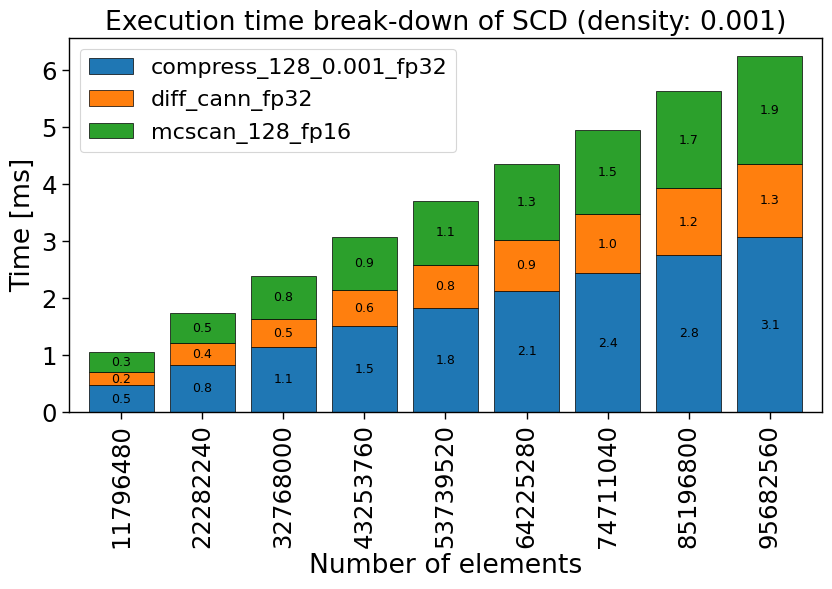

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 8))

pivot_df = segsum_dataframe.pivot(index='size', columns='operator', values='time_ms')
ax = pivot_df.plot(kind='bar', stacked=True, width=0.8, edgecolor='black', linewidth=0.5)

plt.xlabel('Number of elements')
plt.ylabel('Time [ms]')
plt.title('Execution time break-down of SCD (density: 0.001)')

plt.legend(loc="upper left", fontsize='small')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', label_type='center', color='black', fontsize=9)

plt.tight_layout()
plt.savefig("scd_time_breakdown.pdf", bbox_inches='tight')
plt.show()


## SSCR

In [13]:
df4 = pd.read_csv(f"./bench_results_mcscan_128_fp16.csv")
#df4 = pd.read_csv(f"./bench_results_scan_multi_cube_128_fp16.csv")
df5 = pd.read_csv(f"./bench_results_mcscan_128_int8.csv")
#df5 = pd.read_csv(f"./bench_results_scan_multi_cube_128_int8.csv")
df6 = pd.read_csv(f"./bench_results_compress_128_0.001_fp32.csv")
df7 = pd.read_csv(f"./bench_results_seg_scan_mc_revert_0.001_fp32.csv")


segscan_dataframe = pd.concat([df4, df5, df6, df7], ignore_index=True)
segscan_dataframe["time_ms"] = segscan_dataframe["time_us"].astype(float) / 1000.0
segscan_dataframe = segscan_dataframe[segscan_dataframe["size"] > 10_000_000]

segscan_dataframe.head()


,operator,dtype,size,density,outputsize,time_us,time_ms
1,mcscan_128_fp16,fp16,11796480,NaN,11796480,346.23,0.34623
2,mcscan_128_fp16,fp16,22282240,NaN,22282240,540.77,0.54077
3,mcscan_128_fp16,fp16,32768000,NaN,32768000,751.80,0.75180
4,mcscan_128_fp16,fp16,43253760,NaN,43253760,935.52,0.93552
5,mcscan_128_fp16,fp16,53739520,NaN,53739520,1124.80,1.12480


<Figure size 1600x800 with 0 Axes>

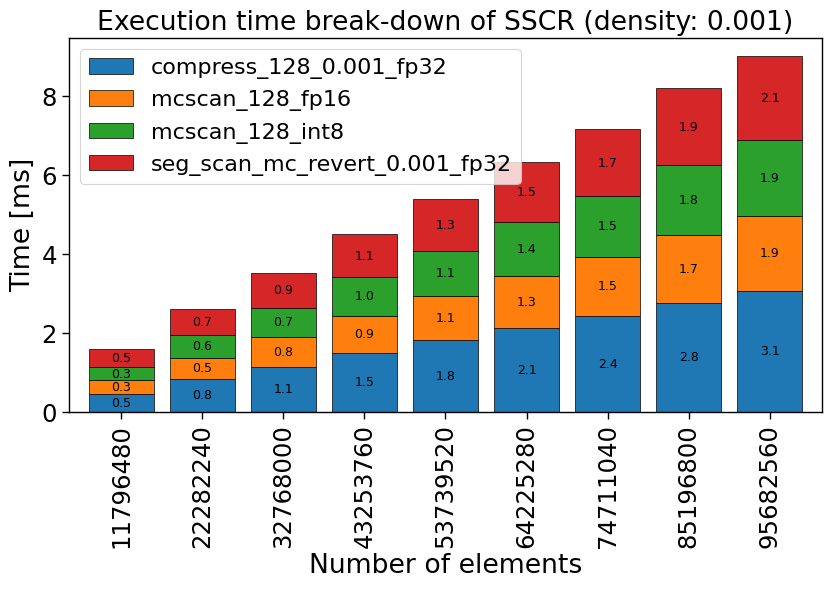

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))

pivot_df = segscan_dataframe.pivot(index='size', columns='operator', values='time_ms')

ax = pivot_df.plot(kind='bar', stacked=True, width=0.8, edgecolor='black', linewidth=0.5)

plt.xlabel('Number of elements')
plt.ylabel('Time [ms]')
plt.title('Execution time break-down of SSCR (density: 0.001)')

plt.legend(loc="upper left", fontsize='small')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', label_type='center', color='black', fontsize=9)

plt.tight_layout()

plt.savefig("sscr_time_breakdown.pdf", bbox_inches='tight')




In [7]:
segscan_dataframe.head(100)

,operator,dtype,size,density,outputsize,time_us,time_ms
2,mcscan_128_fp16,fp16,10813440,NaN,10813440,350.08,0.35008
3,mcscan_128_fp16,fp16,16056320,NaN,16056320,456.68,0.45668
4,mcscan_128_fp16,fp16,21299200,NaN,21299200,543.89,0.54389
5,mcscan_128_fp16,fp16,26542080,NaN,26542080,637.39,0.63739
6,mcscan_128_fp16,fp16,31784960,NaN,31784960,747.97,0.74797
...,...,...,...,...,...,...,...
75,seg_scan_mc_revert_0.001_fp32,fp32,78970880,0.001,78985,1776.53,1.77653
76,seg_scan_mc_revert_0.001_fp32,fp32,84213760,0.001,83995,1913.51,1.91351
77,seg_scan_mc_revert_0.001_fp32,fp32,89456640,0.001,89205,2012.29,2.01229
78,seg_scan_mc_revert_0.001_fp32,fp32,94699520,0.001,94776,2106.28,2.10628


## Combine Charts

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.ticker import EngFormatter

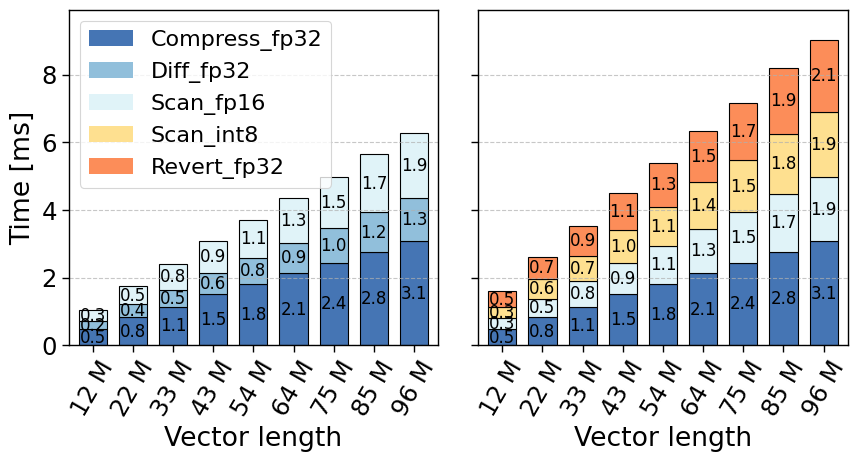

In [19]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import EngFormatter

pivot_df_sscr = segscan_dataframe.pivot(index='size', columns='operator', values='time_ms')
pivot_df_scd = segsum_dataframe.pivot(index='size', columns='operator', values='time_ms')

pivot_df_sscr = pivot_df_sscr.rename(columns={col: f'SSCR_{col}' for col in pivot_df_sscr.columns})
pivot_df_scd = pivot_df_scd.rename(columns={col: f'SCD_{col}' for col in pivot_df_scd.columns})

### Colorbrewer colors
#d73027
#fc8d59
#fee090
#e0f3f8
#91bfdb
#4575b4

sscr_colors = ['#4575b4', '#e0f3f8', '#fee090', '#fc8d59']
scd_colors = ['#4575b4', '#91bfdb', '#e0f3f8']

# sscr_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
# scd_colors = ['#1f77b4', '#7f7f7f', '#ff7f0e']



fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 5), sharey=True)

# pivot_df_sscr.plot(kind='bar', stacked=True, ax=ax1, color=sscr_colors, edgecolor='black', width=0.7, legend=False)
# pivot_df_scd.plot(kind='bar', stacked=True, ax=ax2, color=scd_colors, edgecolor='black', width=0.7, legend=False)
pivot_df_scd.plot(kind='bar', stacked=True, ax=ax1, color=scd_colors, edgecolor='black', width=0.7, legend=False)
pivot_df_sscr.plot(kind='bar', stacked=True, ax=ax2, color=sscr_colors, edgecolor='black', width=0.7, legend=False)

max_y = max(pivot_df_sscr.sum(axis=1).max(), pivot_df_scd.sum(axis=1).max())
ax1.set_ylim(0, max_y * 1.1)
ax2.set_ylim(0, max_y * 1.1)

# ax1.set_title('Multi Core Segmented Scan (density: 0.001) - SSCR Algorithm')
# ax2.set_title('Multi Core Segmented Sum (density: 0.001) - SCD Algorithm')

ax1.set_xlabel('Vector length')
ax2.set_xlabel('Vector length')

ax1.set_ylabel('Time [ms]')
ax2.set_ylabel('')

engFormat = EngFormatter(places=0)
xticks_sscr = [engFormat(n) for n in pivot_df_sscr.index]
xticks_scd = [engFormat(n) for n in pivot_df_scd.index]

ax1.set_xticks(range(len(pivot_df_sscr)))
ax1.set_xticklabels(xticks_sscr, rotation=60)

ax2.set_xticks(range(len(pivot_df_scd)))
ax2.set_xticklabels(xticks_scd, rotation=60)

for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f', label_type='center', color='black', fontsize=12)

for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f', label_type='center', color='black', fontsize=12)

legend_labels_left = ["Compress_fp32", "Scan_fp16", "Scan_int8", "Revert_fp32"]
legend_labels_right = ["Compress_fp32", "Diff_fp32", "Scan_fp16"]
combined_legend_labels = ["Compress_fp32", "Diff_fp32", "Scan_fp16", "Scan_int8", "Revert_fp32"]

legend_colors_left = sscr_colors
legend_colors_right = scd_colors
combined_colors = [sscr_colors[0]] + [scd_colors[1]] + sscr_colors[1:]

legend_elements_left = [Patch(facecolor=legend_colors_left[i], label=legend_labels_left[i]) for i in range(len(legend_labels_left))]
legend_elements_right = [Patch(facecolor=legend_colors_right[i], label=legend_labels_right[i]) for i in range(len(legend_labels_right))]
combined_legend_elements = [Patch(facecolor=combined_colors[i], label=combined_legend_labels[i]) for i in range(len(combined_legend_labels))]

# ax1.legend(handles=legend_elements_left, loc="upper left", fontsize='small', frameon=True)
# ax2.legend(handles=legend_elements_right, loc="upper left", fontsize='small', frameon=True)
ax1.legend(handles=combined_legend_elements, loc="upper left", fontsize='small', frameon=True)
ax1.grid(True, axis='y', linestyle='--', alpha=0.7)
ax2.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("execution_time_breakdown_combined_single_column.pdf", bbox_inches='tight')
